Importok

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from collections.abc import Callable
import yfinance as yf
from datetime import datetime
import yfinance as yf
import pandas as pd

Spot tree

In [2]:
def european_call_payoff(S: float, K: float) -> float:
    return max(S-K, 0.0)
def create_spot_tree(spot: float, spot_mult_up: float, spot_mult_down: float, steps: int) -> list[list[float]]:
    previous_level = [spot]
    tree = [previous_level]
    for _ in range(steps):
        new_level = [s * spot_mult_down for s in previous_level]
        new_level += [previous_level[-1] * spot_mult_up]
        tree += [new_level]
        previous_level = new_level
    return tree

Discounted tree

In [3]:
def create_discounted_price_tree(spot_tree: list[list[float]], discount_factor: float, K: float, diag: int = 0) -> list[list[float]]:
    spot = spot_tree[0][0]
    spot_mult_up = spot_tree[1][-1]/spot
    spot_mult_down = spot_tree[1][0]/spot
    p_up = ((1 / discount_factor - spot_mult_down) /
                   (spot_mult_up - spot_mult_down))
    p_down = 1 - p_up
    steps = len(spot_tree) - 1
    continuation_value_tree = [[np.nan for _ in level] for level in spot_tree]
    if diag > 0:
        print("risk-neutral measure: ")
        print(('%.3f' % p_up, '%.3f' % p_down))
        # init delta tree
        delta_tree = [[np.nan for _ in level] for level in spot_tree[:-1]] #delta makes no sense for leaves
    # going backwards, payoff is known in leaves
    for i in range(len(spot_tree[-1])):
        spot = spot_tree[-1][i]
        discounted_continuation_value = discount_factor**(steps) * european_call_payoff(spot, K)
        continuation_value_tree[-1][i] = discounted_continuation_value
    for step in range(steps - 1, -1, -1):
        for i in range(len(spot_tree[step])):
            continuation_value_tree[step][i] = p_up * continuation_value_tree[step + 1][i] + \
                                            p_down * continuation_value_tree[step + 1][i + 1]
            if diag > 0:
                delta_tree[step][i] = ((continuation_value_tree[step + 1][i] - continuation_value_tree[step + 1][i + 1]) 
                                       / (spot_tree[step + 1][i] - spot_tree[step + 1][i + 1]))
    if diag > 0:
        print("delta: ")
        delta_tree_readable = [['%.3f' % e for e in n] for n in delta_tree]
        print(delta_tree_readable)
    return continuation_value_tree

Balanced tree

In [4]:
def calcBalancedDownStep(spot_mult_up: float, discount_factor: float) -> (float, float):
    return spot_mult_up - 2 * (spot_mult_up - 1 / discount_factor)

Calibration for Apple option with 1 year expiry

In [5]:

ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)
ar = ticker.fast_info['lastPrice']
expirations = ticker.options
if len(expirations) == 0:
    print("Nincsenek elérhető opciók ehhez a részvényhez.")
else:
    target_date = pd.Timestamp.today() + pd.DateOffset(years=1)
    expiry_dates = pd.to_datetime(expirations)
    selected_expiry = expiry_dates[np.abs(expiry_dates - target_date).argmin()]
    selected_expiry = selected_expiry.strftime("%Y-%m-%d")

    print(f"Kiválasztott lejárati dátum (kb. 1 év múlva): {selected_expiry}\n")

opt_chain = ticker.option_chain(selected_expiry)
sor=21 #at the money option at the making of the code
calls = opt_chain.calls
strike= float(calls['strike'][sor])
last_price= float(calls['lastPrice'][sor])
relevant_columns = calls[['strike', 'lastPrice']]
    
relevant_columns = relevant_columns.copy()

Kiválasztott lejárati dátum (kb. 1 év múlva): 2027-03-19



In [6]:
ar

251.63999938964844

In [7]:
relevant_columns


,strike,lastPrice
0,30.0,218.22
1,70.0,195.50
2,90.0,163.00
3,105.0,160.20
4,115.0,140.00
5,120.0,138.97
6,130.0,129.00
7,135.0,123.89
8,145.0,124.50
9,150.0,108.50


In [10]:
steps=1
T=1
discount_factor = np.exp(-0.05 * T) 



In [24]:
def calibrator(last_price: float,ar:float,strike:float,discount_factor:float,steps:int) -> (float, float):
    def optimal(ubecsles):
        ubecsles=ubecsles[0]
        dbecsles=calcBalancedDownStep(ubecsles, discount_factor)
        spot_tree = create_spot_tree(ar, ubecsles, dbecsles, steps)
        price_tree = create_discounted_price_tree(spot_tree, discount_factor, strike)
        model_price = price_tree[0][0]
        return (model_price - last_price)**2
    kezedtibecsles = np.array([1.2])
    kockmnetes_növés = 1.0/discount_factor
    epsilon = 1e-5
    alsóhatár =kockmnetes_növés+epsilon
    limits = [(alsóhatár, 4.0)]
    result = minimize(optimal, kezedtibecsles, bounds=limits)
    return result.x[0], calcBalancedDownStep(result.x[0], discount_factor)
print("Calibrált paraméterek (u, d): " + str(calibrator(last_price,ar,strike,discount_factor,steps)))


Calibrált paraméterek (u, d): (1.2860229909470013, 0.8165192018050469)


A rész

Lépésszám (n):  1 | Lépés DF: 0.95123 | u: 1.2860 | d: 0.8165
Lépésszám (n):  2 | Lépés DF: 0.97531 | u: 1.2244 | d: 0.8263
Lépésszám (n):  4 | Lépés DF: 0.98758 | u: 1.1497 | d: 0.8754
Lépésszám (n): 12 | Lépés DF: 0.99584 | u: 1.0042 | d: 1.0042


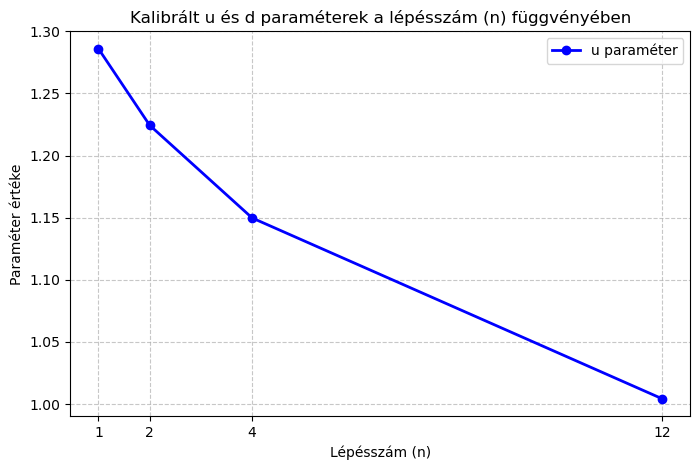

In [25]:
T=1
steps_b=[1,2,4,12]
r=0.05
n_lista=[]
u_lista=[]
d_lista=[]

for current_steps in steps_b:
    dt = T / current_steps
    step_df = np.exp(-r * dt)
    
    u, d = calibrator(last_price, ar, strike, step_df, current_steps)
    n_lista.append(current_steps)
    u_lista.append(u)
    d_lista.append(d)
    
    
    print(f"Lépésszám (n): {current_steps:2d} | Lépés DF: {step_df:.5f} | u: {u:.4f} | d: {d:.4f}")


plt.figure(figsize=(8, 5)) 

plt.plot(n_lista, u_lista, marker='o', label='u paraméter', color='blue', linewidth=2)


plt.title('Kalibrált u és d paraméterek a lépésszám (n) függvényében')
plt.xlabel('Lépésszám (n)')
plt.ylabel('Paraméter értéke')
plt.xticks(steps_b) 
plt.grid(True, linestyle='--', alpha=0.7) 
plt.legend()
plt.show()

B rész

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

r = 0.05
steps = 1 
ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)
ar = ticker.fast_info['lastPrice']
expirations = ticker.options

if len(expirations) == 0:
    print("Nincsenek elérhető opciók ehhez a részvényhez.")
else:
    expiry_dates = pd.to_datetime(expirations)
    target_offsets = [pd.DateOffset(months=3), pd.DateOffset(months=6), pd.DateOffset(years=1)]
    selected_expiries = []
    for offset in target_offsets:
        target_date = pd.Timestamp.today() + offset
        closest_expiry = expiry_dates[np.abs(expiry_dates - target_date).argmin()]
        selected_expiries.append(closest_expiry.strftime("%Y-%m-%d"))
        
    print(f"Kiválasztott lejárati dátumok: {selected_expiries}\n")
    results = []
    for exp_date in selected_expiries:
        expiry_datetime = pd.to_datetime(exp_date)
        days_to_expiry = (expiry_datetime - pd.Timestamp.today()).days
        T = days_to_expiry / 365.0
        df_1step = np.exp(-r * T)
        
        opt_chain = ticker.option_chain(exp_date)
        calls = opt_chain.calls
        idx_atm = (calls['strike'] - ar).abs().idxmin()
        start_idx = max(0, idx_atm - 2)
        end_idx = min(len(calls), idx_atm + 3)
        selected_calls = calls.iloc[start_idx:end_idx]
        for index, row in selected_calls.iterrows():
            strike = float(row['strike'])
            last_price = float(row['lastPrice'])
            if last_price <= 0:
                continue 
            u, d = calibrator(last_price, ar, strike, df_1step, steps)
            
            results.append({
                'Lejárat': exp_date,
                'Futamidő (T)': round(T, 2),
                'Strike': strike,
                'Opciós ár': last_price,
                'u': round(u, 4),
                'd': round(d, 4)
            })

    # Eredmények kiíratása
    df_results = pd.DataFrame(results)
    print(df_results)

Kiválasztott lejárati dátumok: ['2026-06-18', '2026-09-18', '2027-03-19']

       Lejárat  Futamidő (T)  Strike  Opciós ár       u       d
0   2026-06-18          0.23   240.0      22.89  1.1378  0.8856
1   2026-06-18          0.23   245.0      20.06  1.1349  0.8885
2   2026-06-18          0.23   250.0      16.40  1.1254  0.8981
3   2026-06-18          0.23   255.0      13.50  1.1219  0.9015
4   2026-06-18          0.23   260.0      11.00  1.1217  0.9018
5   2026-09-18          0.48   240.0      30.90  1.2054  0.8437
6   2026-09-18          0.48   245.0      27.23  1.1953  0.8537
7   2026-09-18          0.48   250.0      24.08  1.1896  0.8595
8   2026-09-18          0.48   255.0      21.75  1.1905  0.8586
9   2026-09-18          0.48   260.0      18.95  1.1875  0.8616
10  2027-03-19          0.98   230.0      48.40  1.3181  0.7827
11  2027-03-19          0.98   240.0      41.40  1.2994  0.8014
12  2027-03-19          0.98   250.0      35.67  1.2913  0.8095
13  2027-03-19          0.98 

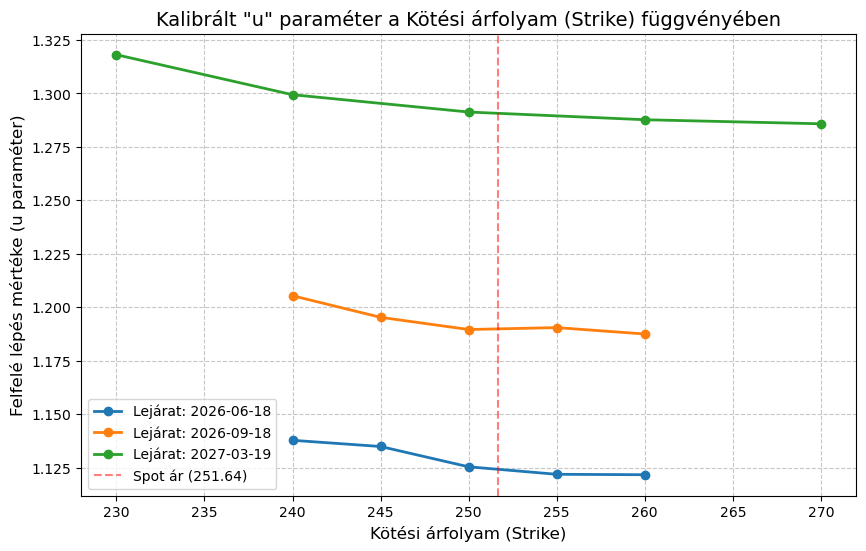

In [20]:

plt.figure(figsize=(10, 6))
egyedi_lejaratok = df_results['Lejárat'].unique()
for lejarat in egyedi_lejaratok:
    
    adott_lejarat_adatai = df_results[df_results['Lejárat'] == lejarat]
    adott_lejarat_adatai = adott_lejarat_adatai.sort_values(by='Strike')
    plt.plot(adott_lejarat_adatai['Strike'], 
             adott_lejarat_adatai['u'], 
             marker='o', 
             linewidth=2,
             label=f'Lejárat: {lejarat}')
plt.title('Kalibrált "u" paraméter a Kötési árfolyam (Strike) függvényében', fontsize=14)
plt.xlabel('Kötési árfolyam (Strike)', fontsize=12)
plt.ylabel('Felfelé lépés mértéke (u paraméter)', fontsize=12)
plt.axvline(x=ar, color='red', linestyle='--', alpha=0.5, label=f'Spot ár ({ar:.2f})')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()